# HTX xData Technical Test Question – Data Scientist (Ivan Lim)

## 1. *Setup*

This notebook was written entirely within an IDE (Pycharm), with the Python 3.13 Interpreter.

---
## 2. *Technical Model Formulation*
---
### 2.1. Definitions

#### Define the set of all students, $S$, the set of all tutors, $T$, and the set of all tuition centre branches $B$.

#### Define fixed parameters (constants):

$k_t \in {0, 1} \; \forall t \in T$, and

$n_s \in \{0, 1\} \; \forall s \in S$, where

$k_t$ denotes tutor $t$'s skills, $n_s$ denotes student $s$'s needs, and $0, 1$ correspond to **Normal**,
**Extensive** respectively.

$p_{t,b} \in \{0, 1, 2\} \; \forall t \in T, \forall b \in B$, where $p_{t, b}$ is the
preference score for tutor $t$ with regards to tuition centre branch $b$; $2$ if the first preferred choice, $1$ if
the second, and $0$ otherwise.

$c_{s, b} \in \{0, 1\} \; \forall s \in S, b \in B$, where $c_{s,b}$ is $1$ if and only if student $s$ is attending classes at tuition centre branch $b$.

Since $p_{t,b}, c_{s, b}$ are used only in preference scoring and always appear together as a product in this model formulation, we can combine them into one parameter
$$q_{s, t} = \sum\limits_{b \in B} p_{t,b} c_{s,b} \quad \forall s \in S, t \in T,$$ where $q_{s,t}$ represents the preference score of tutor $t$ for
the branch attended by student $s$.

$m_t, e_t \in \mathbb{Z}_{\geq 0} \; \forall t \in T$. $m_t$ is the maximum overall capacity of a tutor, and $e_t$ is
the number of their existing students from past assignments.

We assume that $e_t \leq m_t \; \forall t \in T$, because it wouldn't make sense for a tutor to have more existing students than their maximum overall capacity.


#### Define binary ***decision*** variables $x_{s,t}  \in  \{0, 1\} \quad \forall s \in S, t \in T$.

***

### 2.2. *Constraints*
1. Each student must be assigned exactly one tutor.

$$\sum\limits_{t \in T} x_{s,t} = 1 \quad \forall s \in S$$

2. Students with Extensive needs can only be assigned to tutors with Extensive skills.

    $$x_{s,t} \leq k_t \quad \forall \; \text{pairs} \; (s, t) \in S \times T \; \text{such that} \; n_s = 1$$

3. Tutors cannot exceed their remaining available capacity ($m_t - e_t$) when being assigned new students.

    $$\sum\limits_{s \in S} x_{s,t} \leq m_t - e_t \quad \forall t \in T$$

***

### 2.3. *Objective functions*


In both scenarios, two performance metrics are considered:
1. Maximising tutor–branch preference satisfaction, and
2. Minimising total number of assigned tutors (Scenario A) or balancing tutor workload (Scenario B).

We adopt a mixed-sum linear scalarisation to convert a dual-objective problem into a simpler single-objective problem.
Thus, we assign weights ${\alpha, 1 - \alpha} \in [0, 1]$, corresponding to each of the metrics.
However, since the ranges of possible values for each metric can be different, we normalise each metric such that their individual values can only lie in $[0, 1]$.


#### Common metric - maximising tutors' tuition branch preferences

By our preference scoring system defined above, we define the normalised sum of preference scores as
$$\tilde{P} =\frac{1}{P_{max}}\sum\limits_{s \in S}\sum\limits_{t \in T} q_{s,t}x_{s,t},$$
where $P_{max} = 2|S|$ is the upper bound for all possible $P$, since the maximum preference score is 2. A higher value of $\tilde{P}$ is better.

Since, by definition, each new student is studying at exactly one branch, $q_{s,t}$ is simply the preference score of tutor $t$ for that branch.


#### 2.3.1. *Scenario A*

Here, we need to *minimise* the number of assigned tutors and *maximise* the tutor's preference of tuition centre.

First, define binary auxiliary $y_{t} \; \forall t \in T$, where $y_{t} = 1$ if and only if tutor $t$ has been
assigned to at least one new student.

Next, we introduce a constraint to restrict $y_t$, such that $y_t$ must necessarily be equal to 1 if at
least one student is assigned to the tutor.

This constraint replaces constraint $3$.

$$\sum\limits_{s \in S} x_{s, t} \leq (m_t - e_t) y_t \quad \forall t \in T$$

In the other direction:

$$\sum\limits_{s \in S} x_{s, t} \geq y_t \quad \forall t \in T$$

We then obtain $$\tilde{U} = \frac{1}{U_{max}} \sum\limits_{t \in T} y_t,$$ where $U_{max} = |T|$ is the upper bound for
all possible $U$.

Our final objective function is thus $$\bf{min} \; \alpha \tilde{U} - (1 - \alpha) \tilde{P} \text{, or}$$
$$\bf{min} \quad \frac{\alpha}{|T|} \sum\limits_{t \in T} y_t - \frac{(1 - \alpha)}{2|S|}\sum\limits_{s \in
S}\sum\limits_{t \in T} q_{s,t}x_{s,t}$$


#### 2.3.2. *Scenario B*

Balancing tutor workload is less straightforward to define than simply minimising tutor usage. We can define a tutor’s
workload as the total number of students assigned to them, including both existing and newly assigned students.

However, the notion of “balancing” can be interpreted in multiple ways. A natural interpretation is to distribute workload as evenly as possible across tutors.
This can be modelled by minimising the sum of absolute differences between each tutor’s workload and the overall average workload.

An additional consideration is the interpretation of a tutor’s maximum overall capacity (MOC).
If MOC reflects availability or maximum sustainable workload, then balancing raw student counts alone may
unintentionally penalise tutors with greater capacity.

To account for differences in tutor availability, we therefore balance *relative workload*, defined as the ratio of
a tutor’s total assigned students to their maximum capacity. This ensures that workload is distributed equitably
in proportion to each tutor’s capacity.

Under this interpretation, we need to define the following terms:

**Workload definition:**

$L_t = e_t + \sum\limits_{s \in S} x_{s,t} \quad \forall t \in T$, where $L_t$ is the total
workload of tutor $t$ after assigning all new students. The relative workload of a tutor $t$ is then $\rho_t =
\frac{L_t}{m_t}$. The average relative tutor workload is then:

$$\bar{\rho} = \frac{1}{|T|}\sum\limits_{t \in T}\rho_t$$

Since $0 \leq \rho_t \leq 1 \; \forall t \in T$, it follows that $0 \leq \bar{\rho} \leq 1$.

**Auxiliary variables:**

We need a continuous variable $d_t \geq 0 \; \forall t \in T$, representing the absolute
difference between tutor $t$'s relative workload and the relative average.

**Additional constraints:**

These two constraints ensure that $d_t \geq |\rho_t - \bar{\rho}|$. Moreover, since we are
trying to minimise the normalised sum of all $d_t$, that will ensure that $d_t$ is as small as possible, and hence
exactly equal to $|\rho_t - \bar{\rho}|$.

$$\rho_t - \bar{\rho} \leq d_t \quad \forall t \in T$$
$$\bar{\rho} - \rho_t \leq d_t \quad \forall t \in T$$

The normalised expression for our balancing/fairness metric is simply $$\tilde{F} = \frac{1}{|T|} \sum\limits_{t \in
T} d_t$$

Since $|\rho_t - \bar{\rho}| \leq 1 \; \forall t \in T$, it follows that $0 \leq \tilde{F} \leq 1$. A lower value of $\tilde{F}$ is better.

The final objective function for Scenario B is therefore:

$$\bf{min} \quad \alpha \tilde{F} - (1 - \alpha) \tilde{P} \text{, or}$$
$$\bf{min} \quad \frac{\alpha}{|T|} \sum\limits_{t \in T} d_t - \frac{(1 - \alpha)}{2|S|}\sum\limits_{s \in
S}\sum\limits_{t \in T} q_{s,t}x_{s,t}$$.

## 3. Code

Model summary:
Decision variable:
$x_{s,t} = 1$ if student s assigned to tutor t

Constraints:
1. Each student assigned exactly one tutor
2. Skill compatibility
3. Tutor capacity

Preference:

2 = 1st choice, 1 = 2nd choice, 0 = no preference


Objectives:
Scenario A:
min $\alpha$ * tutor_usage − $(1−\alpha)$ * preference

Scenario B:
min $\alpha$ * workload_variance − $(1−\alpha)$ * preference

### 3.1. Setup + load

In [1]:
# Import/install necessary libraries.
from docplex.mp.model import Model
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Define some important objects first.
# Denote Normal skills as 0, and Extensive skills as 1.
skill_int_dict = {'Normal': 0, 'Extensive': 1}

# Open and clean data found in Interview small data.xlsx.
# We need to do some checks to ensure that there are no errors in the given data.

raw_data = pd.read_excel('data/Interview small data.xlsx', sheet_name=None)

# Different sheets.
new_students = raw_data['New Students']  # studentId, tutoringNeed, tuitionCentre
tutor_info = raw_data['Tutor Information']  # tutorId, tutoringSkills, preferredCentre1, preferredCentre2, maxOverallCapacity
existing_students = raw_data['Existing Students']  # tutorId, studentId, tutoringNeed, tuitionCentre, active

### 3.2. Basic data integrity checks + filter for existing active students

In [3]:
# First, check for missing data.
assert not new_students.isnull().values.any(), "Missing values in new students sheet."
assert not tutor_info.isnull().values.any(), "Missing values in tutor info sheet."
assert not existing_students.isnull().values.any(), "Missing values in existing students sheet."

# Next, since there is an 'active' column in existing_students, we filter all students that are currently inactive,
# and drop the column.
existing_students = existing_students[existing_students['active'] == True].drop(columns=['active'])

# Check for duplicate humans.
assert new_students['studentId'].nunique() == len(new_students), "Duplicate student ids found in new students sheet."
assert tutor_info['tutorId'].nunique() == len(tutor_info), "Duplicate tutor ids found in tutor_info sheet."

# Next, look at existing_students. Each student has a unique student id and is assigned to a tutor.
assert existing_students[['tutorId','studentId']].duplicated().sum() == 0, "Duplicate active (tutorId, studentId) rows found."

# Check for invalid values.
assert (tutor_info['maxOverallCapacity'] > 0).all(), "Non-positive maxOverallCapacity found."

### 3.3. Build domain sets + validate categorical values

In [4]:
# Extract unique values from sheets.
tuition_centres = sorted(set(
    new_students['tuitionCentre'].tolist()
    + tutor_info['preferredCentre1'].tolist()
    + tutor_info['preferredCentre2'].tolist()
    + existing_students['tuitionCentre'].tolist()
))

# Sanity checks.
assert tutor_info['preferredCentre1'].isin(tuition_centres).all()
assert tutor_info['preferredCentre2'].isin(tuition_centres).all()
assert new_students['tuitionCentre'].isin(tuition_centres).all()
assert existing_students['tuitionCentre'].isin(tuition_centres).all()

tutoring_skills = sorted(set(new_students['tutoringNeed'].tolist()
                             + existing_students['tutoringNeed'].tolist()
                             + tutor_info['tutoringSkills'].tolist()))

# Check that we don't have any weird tutoring skills.
assert set(tutoring_skills).issubset({'Extensive', 'Normal'}), "Unknown tutoring skill found."

### 3.4. Transform skills to integer codes + define tutor/student ID sets

In [5]:
# Now that all skills have been verified, we can assign each skill a value.
new_students['tutoringNeed'] = new_students['tutoringNeed'].map(skill_int_dict)
tutor_info['tutoringSkills'] = tutor_info['tutoringSkills'].map(skill_int_dict)
existing_students['tutoringNeed'] = existing_students['tutoringNeed'].map(skill_int_dict)

# We assume that tutors are all listed in tutor_info.
tutor_ids = sorted(tutor_info['tutorId'].tolist())

# new students' needs.
student_ids = sorted(new_students['studentId'].tolist())

### 3.5. Build parameter dicts + capacity checks

In [6]:
# tutors' skills.
k = tutor_info.set_index('tutorId')['tutoringSkills'].to_dict()
n = new_students.set_index('studentId')['tutoringNeed'].to_dict()

# maximum overall capacity of each tutor.
m = tutor_info.set_index('tutorId')['maxOverallCapacity'].to_dict()

# Number of existing students for each tutor. Need to include tutors with 0 existing students.
e = {t: 0 for t in tutor_ids}
e.update(existing_students['tutorId'].value_counts().to_dict())

# Capacity checks.
assert all(m[t] >= e[t] for t in tutor_ids), "Some tutors have existing load exceeding max capacity."
assert sum(m[t] - e[t] for t in tutor_ids) >= len(student_ids), "Insufficient total remaining capacity for all new students."

### 3.6. Build preference scoring + derived lookup objects

In [7]:
# Tutor preference scores; dict of (tutor_ids, tuition branch) to preference score: 0,1,2.
p_tb = {(t, b): 0 for t in tutor_ids for b in tuition_centres}

for _, row in tutor_info.iterrows():
    t = row['tutorId']
    p_tb[(t, row['preferredCentre1'])] = 2
    # if 1st == 2nd, keep the 2; else, assign 1.
    p_tb[(t, row['preferredCentre2'])] = max(p_tb[(t, row['preferredCentre2'])], 1)

# sanity check to make sure all values are valid.
assert set(p_tb.values()).issubset({0,1,2})

# dict of student id to branch name.
student_branch_dict = new_students.set_index('studentId')['tuitionCentre'].to_dict()

# preference score of tutor t for the branch attended by student s; dict of (studentId, tutorId) to corresponding score.
q = {(s, t): p_tb[(t, student_branch_dict[s])] for s in student_ids for t in tutor_ids}

### 3.7. Building models in docplex

In [8]:
# Function to build a base model containing all common variables/constraints for both scenarios.
# Set of students, set of teachers.
S, T = student_ids, tutor_ids

def build_base_model(name: str, q: dict, max_pref_score: int):
    """
    builds the base model with all common attributes for solving this problem.
    :param name:            Scenario.
    :param q:               preference score of tutor t for branch attended by student s.
    :param max_pref_score:  the score associated with the 1st preferred choice of branch.
    :return:                the model, the binary variable x, and the preference scoring metric P.
    """
    mdl = Model(name=name)

    # x_s,t is one iff tutor t is assigned to student s.
    x = mdl.binary_var_dict(((s, t) for s in S for t in T), name="x")

    # common constraints.
    # constraint 1: one tutor exactly for each student.
    for s in S:
        mdl.add_constraint(mdl.sum(x[s, t] for t in T) == 1)

    # constraint 2: students who need Extensive skills can only be assigned tutors with Extensive skills.
    mdl.add_constraints(
        x[s, t] == 0
        for s in S for t in T
        if n[s] == 1 and k[t] == 0
    )

    # preference metric (sum of preference scores for all tutors), normalised.
    P = mdl.sum(q[s, t] * x[s, t] for s in S for t in T) / (max_pref_score * len(S))

    mdl.parameters.advance = 2
    return mdl, x, P


def build_scenario_a(model_A: Model, x, P, alpha=0.5):
    # auxiliary variable y_t: tutor activation.
    y = model_A.binary_var_dict(T, name="y")

    # replacement constraint 3: cannot exceed remaining capacity for each tutor. other direction too.
    for t in T:
        model_A.add_constraint(model_A.sum(x[s, t] for s in S) <= y[t] * (m[t] - e[t]))
        model_A.add_constraint(model_A.sum(x[s, t] for s in S) >= y[t])

    # total number of assigned tutors, normalised.
    U = model_A.sum(y[t] for t in T) / len(T)

    # Objective function.
    model_A.minimize(alpha * U - (1 - alpha) * P)

    return model_A, U


def build_scenario_b(model_B: Model, xB, PB, alpha=0.5):
    # Auxiliary variable d: represents absolute difference between tutor's relative workload and the relative average.
    d = model_B.continuous_var_dict(T, lb=0, name="d")

    # Constraint 3: remaining capacity of tutor cannot be exceeded.
    for t in T:
        model_B.add_constraint(model_B.sum(xB[s, t] for s in S) <= (m[t] - e[t]))

    # Workload expressions;
    # L is the workload of a tutor AFTER assigning students.
    L = {t: e[t] + model_B.sum(xB[s, t] for s in S) for t in T}
    # rho is tutor's relative workload (final workload divided by maximum overall capacity).
    rho = {t: L[t] / m[t] for t in T}
    # average relative workload over all tutors.
    rho_bar = model_B.sum(rho[t] for t in T) / len(T)

    # Absolute deviation constraints; to ensure d_t is exactly equal to |rho_t - rho_bar|.
    for t in T:
        model_B.add_constraint(rho[t] - rho_bar <= d[t])
        model_B.add_constraint(rho_bar - rho[t] <= d[t])

    # Workload balancing/fairness metric
    F = model_B.sum(d[t] for t in T) / len(T)

    # Final objective function for scenario B. Using same value of alpha = 0.5, multiply by 10.
    model_B.minimize(10 * alpha * F - (1 - alpha) * PB)

    return model_B, F

#### 3.7.1. Model for scenario A

In [9]:
mdlA, x, P = build_base_model('scenario_a', q, 2)
# default value of alpha is 0.5; this can be changed.
alpha = 0.5
mdlA, U = build_scenario_a(mdlA, x, P, alpha)

#### 3.7.2. Model for scenario B

***NOTE: MODIFICATION TO OBJECTIVE FUNCTION***

If we use our original normalised balancing metric, the specific value we get is $\tilde{F} = \sim0.0793$, which is an order of magnitude lower than the normalised preference score, $\tilde{P} = 0.95$. This means that while all our metrics/scores have been normalized to fit in the range $[0, 1]$, the difference in scale means that any change in preference score affects the objective value more significantly than the same change in the balancing metric.

(Looking at the sensitivity analysis in Section 4.4, the values of $\tilde{F}$ are all approximately $\leq 0.1$.)

Therefore, in practice, we multiply $\tilde{F}$ by 10 for a more comparable scaling, making our tradeoff parameter $\alpha$ more representative of the relative importance between our dual objectives of balancing tutor workloads and maximising tutors' preferences.


In [10]:
# We rename x, P as xB, PB to avoid conflicts with model A.
mdlB, xB, PB = build_base_model('scenario_b', q, 2)
alpha = 0.5
mdlB, F = build_scenario_b(mdlB, xB, PB, alpha)

### 3.8. Initial solves for $\alpha = 0.5$.
#### 3.8.1. Scenario A

For $\alpha = 0.5$, Scenario A assigns all 20 students to suitable tutors while using only 4 tutors *and* achieving $97.5\%$ of the maximum possible preference score (39 out of 40).

This indicates that assigning students to as few tutors as possible does not significantly reduce preference satisfaction in this dataset.

In [11]:
# Solving A first, then printing solutions.
solA = mdlA.solve()

assert solA is not None, "Scenario A: no feasible solution found."
print("solve details for scenario A: ", mdlA.solve_details)
print("objective value:", round(solA.objective_value, 10), "\n")

print(f"Statistics for alpha = {alpha}, Scenario A: ")

# Mapping tutors and students.
tutor_students = {t: [] for t in T}

for s in S:
    for t in T:
        if solA.get_value(x[s, t]) > 0.5:
            tutor_students[t].append(s)
            break

# tutors assigned new students.
tutors_used = sum(1 for t in T if tutor_students[t])
print("Total tutors assigned:", tutors_used, "/", len(T))
print("Normalised sum of tutors, U~:", tutors_used / len(T))

# preference scores.
prefs = [q[s, t] for t in T for s in tutor_students[t]]
raw_pref_score = sum(prefs)

print("Raw sum of preference scores:", raw_pref_score)
print("Normalised sum, P~:", raw_pref_score / (2 * len(S)))
print("Preference distribution:", {v: prefs.count(v) for v in [0, 1, 2]})

# student-tutor assignments.
print("\nNew student/tutor assignments")

for t in sorted(T):
    assigned = tutor_students[t]
    used_new = len(assigned)
    rem_cap = m[t] - e[t]
    print(f"Tutor {t}: {assigned}   (new used {used_new} / remaining {rem_cap}; existing {e[t]} / max {m[t]})")

solve details for scenario A:  status  = integer optimal solution
time    = 0.047 s.
problem = MILP
gap     = 0%

objective value: -0.2875 

Statistics for alpha = 0.5, Scenario A: 
Total tutors assigned: 4 / 10
Normalised sum of tutors, U~: 0.4
Raw sum of preference scores: 39
Normalised sum, P~: 0.975
Preference distribution: {0: 0, 1: 1, 2: 19}

New student/tutor assignments
Tutor A001: ['S0001', 'S0004', 'S0006', 'S0007', 'S0015']   (new used 5 / remaining 8; existing 0 / max 8)
Tutor A002: ['S0009', 'S0014', 'S0016', 'S0017', 'S0020']   (new used 5 / remaining 5; existing 0 / max 5)
Tutor A003: []   (new used 0 / remaining 4; existing 1 / max 5)
Tutor A004: []   (new used 0 / remaining 3; existing 0 / max 3)
Tutor A005: []   (new used 0 / remaining 2; existing 4 / max 6)
Tutor A006: []   (new used 0 / remaining 5; existing 0 / max 5)
Tutor A007: []   (new used 0 / remaining 3; existing 5 / max 8)
Tutor A008: []   (new used 0 / remaining 5; existing 0 / max 5)
Tutor A009: ['S0003',

#### 3.8.2. Scenario B

Looking at the results of the code below, students are distributed very evenly. The relative workloads for all but one tutor hover around $50\%$ to $67\%$ of their MOC, which is approximately a symmetric interval around the average relative workload of $\sim57.3\%$.

In [12]:
# Solving B next. Adjust F tilde.
solB = mdlB.solve()

assert solB is not None, "Scenario B: no feasible solution found."
print("\nsolve details for scenario B: ", mdlB.solve_details)
print("objective value:", round(solB.objective_value, 10), "\n")
print(f"Statistics for alpha = {alpha}, Scenario B:")

# tutor student mapping.
tutor_students_B = {t: [] for t in T}

for s in S:
    for t in T:
        if solB.get_value(xB[s, t]) > 0.5:
            tutor_students_B[t].append(s)
            break

# Preference scoring.
prefs_B = [q[s, t] for t in T for s in tutor_students_B[t]]
raw_pref_score_B = sum(prefs_B)
P_tilde_B = raw_pref_score_B / (2 * len(S))
print("Raw preference score:", raw_pref_score_B)
print("Normalised preference score (P~):", P_tilde_B)
print("Preference distribution:", {v: prefs_B.count(v) for v in [0, 1, 2]})

# Workload balancing.
new_count_B = {t: len(tutor_students_B[t]) for t in T}
L_B = {t: e[t] + new_count_B[t] for t in T}
rho_B = {t: (L_B[t] / m[t]) for t in T}
rho_bar_B = sum(rho_B.values()) / len(T)

d_B = {t: abs(rho_B[t] - rho_bar_B) for t in T}
F_tilde_B = sum(d_B.values()) / len(T)

print("\nWorkload balancing metrics")
print("Average relative workload (rho_bar):", round(rho_bar_B, 10))
print("Normalised balancing metric (F~):", round(F_tilde_B, 10))
print("relative workload min / max:", round(min(rho_B.values()), 10), "/", round(max(rho_B.values()), 10))

# student tutor assignments.
print("\nNew student/tutor assignments (with workload stats)\n")

for t in sorted(T):
    assigned = tutor_students_B[t]
    used_new = len(assigned)
    util = rho_B[t]
    print(
        f"Tutor {t}: {assigned}   "
        f"(new used {used_new} + existing {e[t]} = {used_new + e[t]} / max {m[t]}; "
        f"relative workload {util:.3f})"
    )


solve details for scenario B:  status  = integer optimal solution
time    = 1.329 s.
problem = MILP
gap     = 0%

objective value: -0.1050000055 

Statistics for alpha = 0.5, Scenario B:
Raw preference score: 36
Normalised preference score (P~): 0.9
Preference distribution: {0: 0, 1: 4, 2: 16}

Workload balancing metrics
Average relative workload (rho_bar): 0.5733333333
Normalised balancing metric (F~): 0.069
relative workload min / max: 0.375 / 0.6666666667

New student/tutor assignments (with workload stats)

Tutor A001: ['S0001', 'S0004', 'S0006']   (new used 3 + existing 0 = 3 / max 8; relative workload 0.375)
Tutor A002: ['S0009', 'S0016', 'S0017']   (new used 3 + existing 0 = 3 / max 5; relative workload 0.600)
Tutor A003: ['S0010', 'S0019']   (new used 2 + existing 1 = 3 / max 5; relative workload 0.600)
Tutor A004: ['S0014', 'S0020']   (new used 2 + existing 0 = 2 / max 3; relative workload 0.667)
Tutor A005: []   (new used 0 + existing 4 = 4 / max 6; relative workload 0.667)


## 4. Analysis.

After running the above code, we have now obtained optimal solutions for both scenarios A and B, where $\alpha = 0.5$.

### 4.0. Data analysis

First, we look at the data.

### 4.0.1. Students

There are 20 new students in total; 4 students each studying at the **East, Central** branches and 6 each at the **West, North** branches. Only 2 out of 20 students need tutors with Extensive skills. Of the existing students with assigned tutors, only 12 are active.

### 4.0.2. Tutors

There are 10 tutors in total, 3 of whom have Extensive skills.

```
Counts for 1st and 2nd preferred centres
North:   3, 5
Central: 2, 2
West:    2, 1
East:    3, 2
```

Each of them have variable maximum overall capacities ranging from 3 to 8; and only 6 tutors currently have existing students.

---

### 4.1. Optimal solution for Scenario A.

4 out of 10 tutors are assigned new students, and we obtain a total preference score of 39, out of a maximum of 40. This means that out of all 10 tutors, 7 tutors are actively tutoring students.

<details>
<summary>Show full solution details</summary>

    Tutor A001: ['S0001', 'S0004', 'S0006', 'S0007', 'S0015']
    Tutor A002: ['S0009', 'S0014', 'S0016', 'S0017', 'S0020']
    Tutor A009: ['S0003', 'S0005', 'S0008', 'S0011']
    Tutor A010: ['S0002', 'S0010', 'S0012', 'S0013', 'S0018', 'S0019']
</details>

<br>
The only tutor with an assigned centre that is not their first choice is tutor $A001$, as student $S0006$ is at the **North** branch, while $A001$ prefers the **East** branch. Looking at the data, $S0006$ needs Extensive skills, and the only tutors with Extensive skills ($A001, A006, A009$) prefer **East** or **Central**, so there is no better solution.

(Alternatively, we can achieve the same result by assigning $S0006$ to $A009$.)


### 4.2. Sensitivity analysis for scenario A.

By varying values of $\alpha$ from 0 to 1 in increments of 0.05, we can examine the effects of varying the importance of our two metrics, the number of tutors assigned and the sum of tutor preference scores.

![image.png](data/pics/scenario%20A.png)

We see that it does not matter in Scenario A, because we always have 4 out of 10 tutors assigned while always achieving a total preference score of 39. Even if we discard the trade-off parameter $\alpha$ and simply minimize $\tilde{U} - \tilde{P}$ together, we still obtain the same solution. Our solution for Scenario A is thus robust, because it remains the same despite prioritising one or the other metric more.

---

### 4.3. Optimal solution for Scenario B.

We obtain a total preference score of 36, out of a maximum of 40. This is inevitably worse than in Scenario A, because we prioritise balancing workload in this scenario, and are therefore less flexible in assigning students studying at preferred choices to corresponding tutors.

In our optimal solution, we achieve an average relative workload (total number of students / maximum overall capacity) of $57.3\%$. Our workload balancing metric, $\tilde{F} = 0.069$.

First, recall that:

$$\tilde{F} = \frac{1}{|T|} \sum\limits_{t \in T} d_t = \frac{1}{|T|} \sum\limits_{t \in T} |\rho_t - \bar{\rho}|$$

where $\rho_t, \bar{\rho}$ are the relative workload of tutor $t$ and the overall average relative workload (ARW).

This means that, if $\tilde{F} = 0.1$, the relative workload of each tutor deviates from the ARW by $10\%$ on average.

Hence, on average, the difference between any tutor's relative workload and the overall ARW is $6.9\%$, which means we have succeeded in balancing workloads between tutors.

Only tutors $A005$ and $A007$ are not assigned any new students, because they have relative workloads of $66.7\%$ and $62.5\%$ respectively from their existing students.

```
Tutor A001: ['S0001', 'S0004', 'S0006']   (new used 3 + existing 0 = 3 / max 8; util 0.375)
Tutor A002: ['S0009', 'S0016', 'S0017']   (new used 3 + existing 0 = 3 / max 5; util 0.600)
Tutor A003: ['S0010', 'S0019']            (new used 2 + existing 1 = 3 / max 5; util 0.600)
Tutor A004: ['S0014', 'S0020']            (new used 2 + existing 0 = 2 / max 3; util 0.667)
Tutor A005: []                            (new used 0 + existing 4 = 4 / max 6; util 0.667)
Tutor A006: ['S0007', 'S0011', 'S0015']   (new used 3 + existing 0 = 3 / max 5; util 0.600)
Tutor A007: []                            (new used 0 + existing 5 = 5 / max 8; util 0.625)
Tutor A008: ['S0003', 'S0013', 'S0018']   (new used 3 + existing 0 = 3 / max 5; util 0.600)
Tutor A009: ['S0005', 'S0008']            (new used 2 + existing 0 = 2 / max 4; util 0.500)
Tutor A010: ['S0002', 'S0012']            (new used 2 + existing 2 = 4 / max 8; util 0.500)
```

Tutor $A001$ is the outlier here, since their relative workload is the lowest at $37.5\%$. This is partially explained by their MOC, which is the largest at 8.

If we look into the given data, we see that tutor **A001** has Extensive skills, so this large deviation is not because they cannot meet students' needs.
Their 1st choice of tuition centre is **East**, but only 4 out of 20 students are studying at the East branch, which is the lowest (equal with Central). Since we are trying to maximise preference scores, assigning more non-East students to **A001** might give them a fairer workload compared to the other tutors, but it would reduce the overall preference score. The reason for **A001**'s outlier workload is thus because of their location preferences.


### 4.4. Sensitivity analysis for scenario B.

By varying values of $\alpha$ from 0 to 1 in increments of 0.05, we can examine the effects of varying the importance of our two metrics, the sum of tutor preference scores, and the fairness/workload balancing metric, which is the sum of the absolute differences between tutors' relative workloads and the average relative workload.


![image.png](data/pics/average%20relative%20workload.png)

For all solutions found at each value of $\alpha$, the average relative workload is constant at $57.3\%$.

![image.png](data/pics/workload%20balancing.png)

Only three distinct solutions can be found here on the Pareto frontier.

We then have three distinct optimal solutions with metrics:
```
preference score: 36; F~ = 0.069 approx
preference score: 38; F~ = 0.079 approx
preference score: 39; F~ = 0.105 approx
```

You can see the exact solutions below.

##### 4.4.1. Common trends

Tutor $A001$ is consistently the tutor with the lowest relative workload ($12.5\%, 25\%, 37.5\%$), as they have the highest MOC of 8 and prefer the **East** tuition centre branch, where only 4 out of 20 new students are studying at.

Tutors $A005$ and $A007$ are not assigned any new students, because they already have relative workloads ($\sum66.7\%, 62.5\%$ respectively) just from their existing students alone.

Students $(S0002, S0012),\;(S0009, S0016),\;(S0010, S0019),\;S0014$ are always assigned to the same tutors: $A010,\;A002,\;A003,\;A004$ respectively.

There doesn't seem to be any specific reasons why CPLEX provides this; all skill needs are met, and these students are all studying at their respective tutors' preferred branches.


##### 4.4.2. Differences between solutions

Each solution makes trade-offs between maximising tutors' preferences and balancing tutor workloads in different ways.

Across the three solutions, A001 is assigned 1, 2, and 3 new students respectively, giving relative workloads of $12.5\%, 25\%, 37.5\%$. Correspondingly, A010 sheds one student per solution (workload drops from $75\% \to 62.5\% \to 50\%$), with the freed students $S0018$, $S0013$ redistributed to A008. This rebalancing is what causes the decrease in F~\tilde{F}, but it comes at a preference cost, since A001's preferred branch is **East**, which has only 4 out of 20 new students.

To compensate and recover preference score where possible, $A006$, $A008$, and $A009$ are reshuffled across solutions. For example, $S0006$ , who requires Extensive skills, is handled by $A009$ in Solution 1, then moved to A001 in Solutions 2 and 3.

The net result is a clear three-way Pareto frontier.

The solution with highest balancing of workload sacrifices 3 preference points relative to the least balanced, and the solution with the highest preference score has an average relative workload difference from mean of $\sim10.4\%$, compared to the lowest of $\sim6.9\%$, and there is a "balanced" solution that sits in the middle.

No solution achieves both optimal preference score and optimal workload balance simultaneously.

---

<details >
<summary> Full details for optimal solutions </summary>
For reference, these are the 3 unique optimal solutions obtained when varying $\alpha$:

    preference score: 36; F~ = 0.069 approx 0.35 <= alpha <= 1.0
    Tutor 'A001': ['S0007']                            (new used 1 + existing 0 = 1 / max 8; util 0.125) pref score (%): 100
    Tutor 'A002': ['S0009', 'S0016', 'S0020']          (new used 3 + existing 0 = 3 / max 5; util 0.600) pref score (%): 100
    Tutor 'A003': ['S0010', 'S0019']                   (new used 2 + existing 1 = 3 / max 5; util 0.600) pref score (%): 100
    Tutor 'A004': ['S0014', 'S0017']                   (new used 2 + existing 0 = 2 / max 3; util 0.667) pref score (%): 100
    Tutor 'A005': []                                   (new used 0 + existing 4 = 4 / max 6; util 0.667) pref score (%): N/A
    Tutor 'A006': ['S0001', 'S0004', 'S0015']          (new used 3 + existing 0 = 3 / max 5; util 0.600) pref score (%): 100
    Tutor 'A007': []                                   (new used 0 + existing 5 = 5 / max 8; util 0.625) pref score (%): N/A
    Tutor 'A008': ['S0003', 'S0005', 'S0008']          (new used 3 + existing 0 = 3 / max 5; util 0.600) pref score (%): 100
    Tutor 'A009': ['S0006', 'S0011']                   (new used 2 + existing 0 = 2 / max 4; util 0.500) pref score (%): 75
    Tutor 'A010': ['S0002', 'S0012', 'S0013', 'S0018'] (new used 4 + existing 2 = 6 / max 8; util 0.750) pref score (%): 100

    preference score: 38; F~ = 0.079333 approx 0.1 <= alpha <= 0.30
    Tutor 'A001': ['S0006', 'S0015']            (new used 2 + existing 0 = 2 / max 8; util 0.250) pref score (%): 75
    Tutor 'A002': ['S0009', 'S0016', 'S0020']   (new used 3 + existing 0 = 3 / max 5; util 0.600) pref score (%): 100
    Tutor 'A003': ['S0010', 'S0019']            (new used 2 + existing 1 = 3 / max 5; util 0.600) pref score (%): 100
    Tutor 'A004': ['S0014', 'S0017']            (new used 2 + existing 0 = 2 / max 3; util 0.667) pref score (%): 100
    Tutor 'A005': []                            (new used 0 + existing 4 = 4 / max 6; util 0.667) pref score (%): N/A
    Tutor 'A006': ['S0001', 'S0004', 'S0007']   (new used 3 + existing 0 = 3 / max 5; util 0.600) pref score (%): 100
    Tutor 'A007': []                            (new used 0 + existing 5 = 5 / max 8; util 0.625) pref score (%): N/A
    Tutor 'A008': ['S0005', 'S0008', 'S0018']   (new used 3 + existing 0 = 3 / max 5; util 0.600) pref score (%): 83.3
    Tutor 'A009': ['S0003', 'S0011']            (new used 2 + existing 0 = 2 / max 4; util 0.500) pref score (%): 100
    Tutor 'A010': ['S0002', 'S0012', 'S0013']   (new used 3 + existing 2 = 5 / max 8; util 0.625) pref score (%): 100

    preference score: 39; F~ = 0.104333 approx, 0 <= alpha <= 0.05
    Tutor 'A001': ['S0001', 'S0004', 'S0006']   (new used 3 + existing 0 = 3 / max 8; util 0.375) pref score (%): 83.3
    Tutor 'A002': ['S0009', 'S0016', 'S0017']   (new used 3 + existing 0 = 3 / max 5; util 0.600) pref score (%): 100
    Tutor 'A003': ['S0010', 'S0019']            (new used 2 + existing 1 = 3 / max 5; util 0.600) pref score (%): 100
    Tutor 'A004': ['S0014', 'S0020']            (new used 2 + existing 0 = 2 / max 3; util 0.667) pref score (%): 100
    Tutor 'A005': []                            (new used 0 + existing 4 = 4 / max 6; util 0.667) pref score (%): N/A
    Tutor 'A006': ['S0007', 'S0011', 'S0015']   (new used 3 + existing 0 = 3 / max 5; util 0.600) pref score (%): 83.3
    Tutor 'A007': []                            (new used 0 + existing 5 = 5 / max 8; util 0.625) pref score (%): N/A
    Tutor 'A008': ['S0003', 'S0013', 'S0018']   (new used 3 + existing 0 = 3 / max 5; util 0.600) pref score (%): 66.7
    Tutor 'A009': ['S0005', 'S0008']            (new used 2 + existing 0 = 2 / max 4; util 0.500) pref score (%): 100
    Tutor 'A010': ['S0002', 'S0012']            (new used 2 + existing 2 = 4 / max 8; util 0.500) pref score (%): 100

</details>
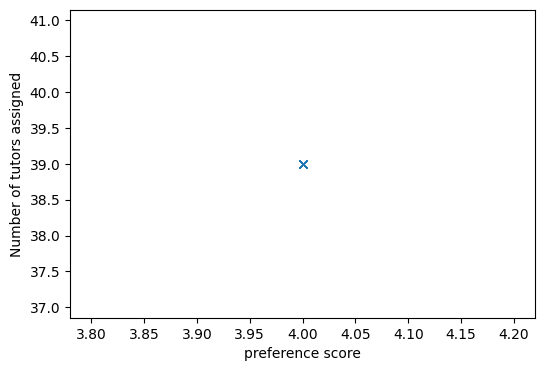
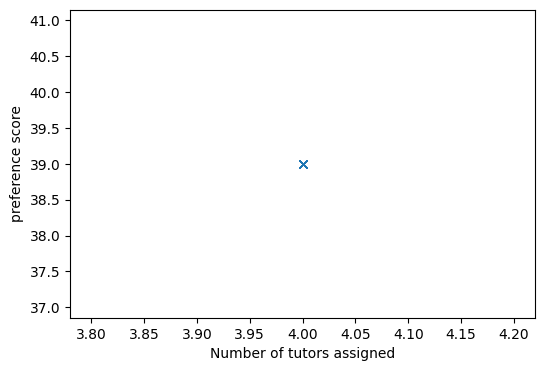
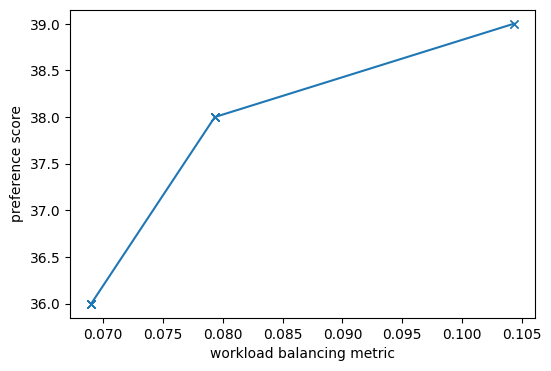
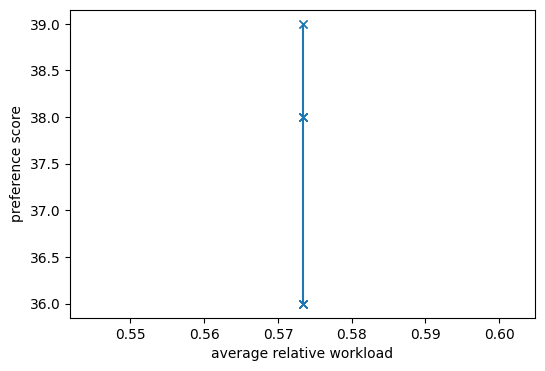

### 4.5. Robustness of selected preference scoring metric.

In both scenarios, for each tutor, we assigned the 1st and 2nd preferred choice of tuition centre branch with scores of 2 and 1 respectively, and 0 if their assigned branch was neither of the two.

In this section, we examine two different preferencing scoring metrics to test the robustness of our chosen metric.

1. `1st choice: 5, 2nd choice: 2, no choice: 0` - this breaks the implied scaling of importance between the 1st and 2nd choices.
2. `1st choice: 1, 2nd choice and no choice: 0` - this only rewards assigning a student to a tutor if the student is studying at their 1st choice.

---

#### 4.5.1. Effects on scenario A.

For both `5,2,0` and `1,0,0`, the total number of tutors assigned new students remains constant at 4. The normalised sum of preference scores remains high at $97\%$ and $95\%$ respectively, compared to $97.5\%$ originally. Furthermore, the students assigned to each tutor are exactly the same.


This indicates that in Scenario A, our chosen preference scoring metric is highly robust.

<details><summary>Full solution details for scenario A</summary>

    Statistics for alpha = 0.5, Scenario A, preference scoring [5,2,0]:
    Total tutors assigned: 4 / 10
    Normalised sum of tutors, U~: 0.4
    Raw sum of preference scores: 97
    Normalised sum, P~: 0.97
    Preference distribution: {0: 0, 2: 1, 5: 19}

    New student/tutor assignments
    Tutor A001: ['S0001', 'S0004', 'S0006', 'S0007', 'S0015']   (new used 5 / remaining 8; existing 0 / max 8)
    Tutor A002: ['S0009', 'S0014', 'S0016', 'S0017', 'S0020']   (new used 5 / remaining 5; existing 0 / max 5)
    Tutor A009: ['S0003', 'S0005', 'S0008', 'S0011']   (new used 4 / remaining 4; existing 0 / max 4)
    Tutor A010: ['S0002', 'S0010', 'S0012', 'S0013', 'S0018', 'S0019']   (new used 6 / remaining 6; existing 2 / max 8)

    Statistics for alpha = 0.5, Scenario A, preference scoring [1,0,0]:
    Total tutors assigned: 4 / 10
    Normalised sum of tutors, U~: 0.4
    Raw sum of preference scores: 19
    Normalised sum, P~: 0.95
    Preference distribution: {0: 1, 1: 19}

    New student/tutor assignments
    Tutor A001: ['S0001', 'S0004', 'S0006', 'S0007', 'S0015']   (new used 5 / remaining 8; existing 0 / max 8)
    Tutor A002: ['S0009', 'S0014', 'S0016', 'S0017', 'S0020']   (new used 5 / remaining 5; existing 0 / max 5)
    Tutor A009: ['S0003', 'S0005', 'S0008', 'S0011']   (new used 4 / remaining 4; existing 0 / max 4)
    Tutor A010: ['S0002', 'S0010', 'S0012', 'S0013', 'S0018', 'S0019']   (new used 6 / remaining 6; existing 2 / max 8)
</details>

---

#### 4.5.2. Effects on scenario B.

For both `5,2,0` and `1,0,0`, the normalised preference scores remain high at $89\%$ and $85\%$ respectively, compared to the original of $90\%$. Additionally, the workload balancing metric is $\tilde{F} = 0.069$, the same for all preference scoring metrics.

Finally, looking at the optimal solutions obtained for both alternative preference scoring metrics, we see that each tutor has been assigned the same exact number of new students as in the original optimal solution, and has the exact same relative workload, even though some tutors have been assigned different students.

We can therefore conclude that our chosen preference scoring metric is highly robust over both Scenario A and B.

<details><summary>Full solution details for scenario B</summary>

    Statistics for alpha = 0.5, Scenario B, preference scoring [5,2,0]:
    Raw preference score: 89
    Normalised preference score (P~): 0.89
    Preference distribution: {0: 1, 2: 2, 5: 17}

    Workload balancing metrics
    Average relative workload (rho_bar): 0.5733333333
    Normalised balancing metric (F~): 0.069
    relative workload min / max: 0.375 / 0.6666666667

    New student/tutor assignments (with workload stats)

    Tutor A001: ['S0001', 'S0006', 'S0007']   (new used 3 + existing 0 = 3 / max 8; relative workload 0.375)
    Tutor A002: ['S0009', 'S0016', 'S0017']   (new used 3 + existing 0 = 3 / max 5; relative workload 0.600)
    Tutor A003: ['S0012', 'S0018']   (new used 2 + existing 1 = 3 / max 5; relative workload 0.600)
    Tutor A004: ['S0014', 'S0020']   (new used 2 + existing 0 = 2 / max 3; relative workload 0.667)
    Tutor A005: []   (new used 0 + existing 4 = 4 / max 6; relative workload 0.667)
    Tutor A006: ['S0004', 'S0015', 'S0019']   (new used 3 + existing 0 = 3 / max 5; relative workload 0.600)
    Tutor A007: []   (new used 0 + existing 5 = 5 / max 8; relative workload 0.625)
    Tutor A008: ['S0003', 'S0005', 'S0013']   (new used 3 + existing 0 = 3 / max 5; relative workload 0.600)
    Tutor A009: ['S0008', 'S0011']   (new used 2 + existing 0 = 2 / max 4; relative workload 0.500)
    Tutor A010: ['S0002', 'S0010']   (new used 2 + existing 2 = 4 / max 8; relative workload 0.500)

    Statistics for alpha = 0.5, Scenario B, preference scoring [1,0,0]:
    Raw preference score: 17
    Normalised preference score (P~): 0.85
    Preference distribution: {0: 3, 1: 17}

    Workload balancing metrics
    Average relative workload (rho_bar): 0.5733333333
    Normalised balancing metric (F~): 0.069
    relative workload min / max: 0.375 / 0.6666666667

    New student/tutor assignments (with workload stats)

    Tutor A001: ['S0001', 'S0007', 'S0019']   (new used 3 + existing 0 = 3 / max 8; relative workload 0.375)
    Tutor A002: ['S0009', 'S0014', 'S0020']   (new used 3 + existing 0 = 3 / max 5; relative workload 0.600)
    Tutor A003: ['S0002', 'S0012']   (new used 2 + existing 1 = 3 / max 5; relative workload 0.600)
    Tutor A004: ['S0016', 'S0017']   (new used 2 + existing 0 = 2 / max 3; relative workload 0.667)
    Tutor A005: []   (new used 0 + existing 4 = 4 / max 6; relative workload 0.667)
    Tutor A006: ['S0004', 'S0013', 'S0015']   (new used 3 + existing 0 = 3 / max 5; relative workload 0.600)
    Tutor A007: []   (new used 0 + existing 5 = 5 / max 8; relative workload 0.625)
    Tutor A008: ['S0003', 'S0005', 'S0008']   (new used 3 + existing 0 = 3 / max 5; relative workload 0.600)
    Tutor A009: ['S0006', 'S0011']   (new used 2 + existing 0 = 2 / max 4; relative workload 0.500)
    Tutor A010: ['S0010', 'S0018']   (new used 2 + existing 2 = 4 / max 8; relative workload 0.500)
</details>

### 4.6. Choice of workload balancing metric in Scenario B

In this final section of the report, we examine the choice of workload balancing metric in Scenario B.

Our metric is the sum of the absolute differences between a tutor's relative workload (total number of assigned students / MOC) and the average relative workload, normalised by dividing by the total number of tutors.

This takes into consideration a tutor's MOC (which we can choose to interpret variously as availability or maximum sustainable workload) by minimising this sum, we try to ensure each tutor's workload is comparable to other tutors' workloads.

Depending on how exactly we interpret "balancing workload" (as per the assessment brief), we can come up with at least two other metrics.

---

1. `Balancing absolute workload instead of relative workload`: We do not divide by MOC, and consider only the total number of assigned students, new or existing.

This is a slightly naive interpretation, because we are essentially stating that the most important thing for student assignment fairness is the total number of students a tutor is teaching.

The optimal solution obtained has a preference score of 35, which is lower than the original score of 36. Each tutor is teaching 2 to 5 students in total in the original and this metric, but looking at the counts: `{2: 1, 3: 6, 4: 1, 5: 1}` (new) and `{2: 2, 3: 5, 4: 2, 5: 1}` (original), this metric groups workload more closely around the global constant average of 3.2 students per tutor. This metric therefore performs slightly worse than the original metric.


<details><summary>Full solution details</summary>

    Statistics for alpha = 0.5, Scenario B:
    Raw preference score: 35
    Normalised preference score (P~): 0.875
    Preference distribution: {0: 1, 1: 3, 2: 16}

    Workload balancing metrics
    Average workload (L_bar): 3.2
    Normalised balancing metric (F~): 0.52
    relative workload min / max: 2 / 5

    New student/tutor assignments (with workload stats)

    Tutor A001: ['S0001', 'S0006']            (new used 2 + existing 0 = 2 / max 8)
    Tutor A002: ['S0009', 'S0016', 'S0017']   (new used 3 + existing 0 = 3 / max 5)
    Tutor A003: ['S0002', 'S0012']            (new used 2 + existing 1 = 3 / max 5)
    Tutor A004: ['S0013', 'S0014', 'S0020']   (new used 3 + existing 0 = 3 / max 3)
    Tutor A005: []                            (new used 0 + existing 4 = 4 / max 6)
    Tutor A006: ['S0004', 'S0007', 'S0015']   (new used 3 + existing 0 = 3 / max 5)
    Tutor A007: []                            (new used 0 + existing 5 = 5 / max 8)
    Tutor A008: ['S0003', 'S0010', 'S0018']   (new used 3 + existing 0 = 3 / max 5)
    Tutor A009: ['S0005', 'S0008', 'S0011']   (new used 3 + existing 0 = 3 / max 4)
    Tutor A010: ['S0019']   (new used 1 + existing 2 = 3 / max 8
</details>

---

2. `Min-max workload`: We try to minimise the maximum workload of each tutor. This will try to reduce workload as much as possible for each tutor, but the problem is that this metric will ignore tutors with very little workload, so it is not very good in balancing workload compared to the other two metrics.

Interestingly enough, we can improve the preference score up to 39 out of 40. However, each tutor is now teaching 0 to 5 students each, which has worsened the spread, and trying to minimise the maximum workload over all tutors has failed, because we still hit a maximum of 5 students. Looking at the count: `{0: 6, 1: 1, 2: 1, 4: 1, 5: 1}`, we see that the workload is definitely NOT balanced, because a large number of tutors are not teaching any students at all while other tutors are working more.

If we compare this to the optimal solution for Scenario A, which shares the same preference score, we see that it is still a big improvement in terms of balancing workload, since that solution assigns all new students to 4 tutors, while this assigns new students to 8 tutors.

<details><summary>Full solution details</summary>

    Statistics for alpha = 0.5, Scenario B:
    Raw preference score: 39
    Normalised preference score (P~): 0.975
    Preference distribution: {0: 0, 1: 1, 2: 19}

    Workload balancing metrics
    Normalised balancing metric (F~): 0.5
    workload min / max: 0 / 5

    New student/tutor assignments (with workload stats)

    Tutor A001: []                                     (new used 0 + existing 0 = 0 / max 8)
    Tutor A002: ['S0017']                              (new used 1 + existing 0 = 1 / max 5)
    Tutor A003: ['S0002', 'S0010', 'S0012', 'S0019']   (new used 4 + existing 1 = 5 / max 5)
    Tutor A004: ['S0009', 'S0016', 'S0020']            (new used 3 + existing 0 = 3 / max 3)
    Tutor A005: ['S0014']                              (new used 1 + existing 4 = 5 / max 6)
    Tutor A006: ['S0001', 'S0004', 'S0007', 'S0015']   (new used 4 + existing 0 = 4 / max 5)
    Tutor A007: []                                     (new used 0 + existing 5 = 5 / max 8)
    Tutor A008: ['S0003', 'S0005', 'S0008']            (new used 3 + existing 0 = 3 / max 5)
    Tutor A009: ['S0006', 'S0011']                     (new used 2 + existing 0 = 2 / max 4)
    Tutor A010: ['S0013', 'S0018']                     (new used 2 + existing 2 = 4 / max 8)
</details>

---

In conclusion, our choice of workload balancing metric in Scenario B is justified.

## 5. Appendix: Code for analysis and visualisation

***NOTE:*** the report ends here. This section contains code that generates the visuals and data used for the report.

Much of the code is replicated from above.

First, the code for testing robustness of our preference ranking metric.

In [13]:
# First, code for testing robustness of preference ranking metric.
# the original is 2/1/0. We try 5/2/0 (to break scale), 1/0/0 (only 1st choice matches are rewarded).
# This copies code from above.

metrics = [(5,2,0), (1,0,0)]
qs = []
for each in metrics:
    choice1 = each[0]
    choice2 = each[1]
    nochoice = each[2]
    # Tutor preference scores; dict of (tutor_ids, tuition branch) to preference score: 0,1,2.
    p_tb = {(t, b): nochoice for t in tutor_ids for b in tuition_centres}

    for _, row in tutor_info.iterrows():
        t = row['tutorId']
        p_tb[(t, row['preferredCentre1'])] = choice1
        # if 1st == 2nd, keep the 2; else, assign 1.
        p_tb[(t, row['preferredCentre2'])] = max(p_tb[(t, row['preferredCentre2'])], choice2)

    # sanity check to make sure all values are valid.
    assert set(p_tb.values()).issubset(set(each))

    # dict of student id to branch name.
    student_branch_dict = new_students.set_index('studentId')['tuitionCentre'].to_dict()

    # preference score of tutor t for the branch attended by student s; dict of (studentId, tutorId) to corresponding score.
    q_alt = {(s, t): p_tb[(t, student_branch_dict[s])] for s in student_ids for t in tutor_ids}
    qs.append(q_alt)

# Now build models again.
for q_alt, metric in zip(qs, metrics):
    p_score_max = max(metric)

    #### model A ####
    mdlA_alt, x_alt, P_alt = build_base_model('scenario_a', q_alt, p_score_max)
    mdlA_alt, _ = build_scenario_a(mdlA_alt, x_alt, P_alt)

    # Solving A first, then printing solutions.
    solA = mdlA_alt.solve()

    ### print stuff. You can ignore this until the next section of code.

    assert solA is not None, "Scenario A: no feasible solution found."
    print("solve details for scenario A: ", mdlA_alt.solve_details)
    print("objective value:", round(solA.objective_value, 10), "\n")

    print(f"Statistics for alpha = {alpha}, Scenario A: ")

    # Mapping tutors and students.
    tutor_students = {t: [] for t in T}

    for s in S:
        for t in T:
            if solA.get_value(x_alt[s, t]) > 0.5:
                tutor_students[t].append(s)
                break

    # tutors assigned new students.
    tutors_used = sum(1 for t in T if tutor_students[t])
    print("Total tutors assigned:", tutors_used, "/", len(T))
    print("Normalised sum of tutors, U~:", tutors_used / len(T))

    # preference scores.
    prefs = [q_alt[s, t] for t in T for s in tutor_students[t]]
    raw_pref_score = sum(prefs)

    print("Raw sum of preference scores:", raw_pref_score)
    print("Normalised sum, P~:", raw_pref_score / (p_score_max * len(S)))
    print("Preference distribution:", {v: prefs.count(v) for v in sorted(metric)})

    # student-tutor assignments.
    print("\nNew student/tutor assignments")

    for t in sorted(T):
        assigned = tutor_students[t]
        used_new = len(assigned)
        rem_cap = m[t] - e[t]
        print(f"Tutor {t}: {assigned}   (new used {used_new} / remaining {rem_cap}; existing {e[t]} / max {m[t]})")

    #### model B ####

    mdlB_alt, xB_alt, PB_alt = build_base_model('scenario_b', q_alt, p_score_max)
    mdlB_alt, _ = build_scenario_b(mdlB_alt, xB_alt, PB_alt)

    # Solving B next. Adjust F tilde.
    solB = mdlB_alt.solve()

    ### print stuff. You can ignore this.

    assert solB is not None, "Scenario B: no feasible solution found."
    print("\nsolve details for scenario B: ", mdlB_alt.solve_details)
    print("objective value:", round(solB.objective_value, 10), "\n")
    print(f"Statistics for alpha = {alpha}, Scenario B:")

    # tutor student mapping.
    tutor_students_B = {t: [] for t in T}

    for s in S:
        for t in T:
            if solB.get_value(xB_alt[s, t]) > 0.5:
                tutor_students_B[t].append(s)
                break

    # Preference scoring.
    prefs_B = [q_alt[s, t] for t in T for s in tutor_students_B[t]]
    raw_pref_score_B = sum(prefs_B)
    P_tilde_B = raw_pref_score_B / (p_score_max * len(S))
    print("Raw preference score:", raw_pref_score_B)
    print("Normalised preference score (P~):", P_tilde_B)
    print("Preference distribution:", {v: prefs_B.count(v) for v in sorted(metric)})

    # Workload balancing.
    new_count_B = {t: len(tutor_students_B[t]) for t in T}
    L_B = {t: e[t] + new_count_B[t] for t in T}
    rho_B = {t: (L_B[t] / m[t]) for t in T}
    rho_bar_B = sum(rho_B.values()) / len(T)

    d_B = {t: abs(rho_B[t] - rho_bar_B) for t in T}
    F_tilde_B = sum(d_B.values()) / len(T)

    print("\nWorkload balancing metrics")
    print("Average relative workload (rho_bar):", round(rho_bar_B, 10))
    print("Normalised balancing metric (F~):", round(F_tilde_B, 10))
    print("relative workload min / max:", round(min(rho_B.values()), 10), "/", round(max(rho_B.values()), 10))

    # student tutor assignments.
    print("\nNew student/tutor assignments (with workload stats)\n")

    for t in sorted(T):
        assigned = tutor_students_B[t]
        used_new = len(assigned)
        util = rho_B[t]
        print(
            f"Tutor {t}: {assigned}   "
            f"(new used {used_new} + existing {e[t]} = {used_new + e[t]} / max {m[t]}; "
            f"relative workload {util:.3f})"
        )


solve details for scenario A:  status  = integer optimal solution
time    = 0.063 s.
problem = MILP
gap     = 0%

objective value: -0.285 

Statistics for alpha = 0.5, Scenario A: 
Total tutors assigned: 4 / 10
Normalised sum of tutors, U~: 0.4
Raw sum of preference scores: 97
Normalised sum, P~: 0.97
Preference distribution: {0: 0, 2: 1, 5: 19}

New student/tutor assignments
Tutor A001: ['S0001', 'S0004', 'S0006', 'S0007', 'S0015']   (new used 5 / remaining 8; existing 0 / max 8)
Tutor A002: ['S0009', 'S0014', 'S0016', 'S0017', 'S0020']   (new used 5 / remaining 5; existing 0 / max 5)
Tutor A003: []   (new used 0 / remaining 4; existing 1 / max 5)
Tutor A004: []   (new used 0 / remaining 3; existing 0 / max 3)
Tutor A005: []   (new used 0 / remaining 2; existing 4 / max 6)
Tutor A006: []   (new used 0 / remaining 5; existing 0 / max 5)
Tutor A007: []   (new used 0 / remaining 3; existing 5 / max 8)
Tutor A008: []   (new used 0 / remaining 5; existing 0 / max 5)
Tutor A009: ['S0003', '

Next, the code for testing different workload balancing metrics. Again, most of the code is copied from above.

In [14]:
# Code for testing difference in absolute workload
mdlB_alt, xB_alt, PB_alt = build_base_model('scenario_b', q, 2)

# We can't use build_scenario_b, because we need to change the metric used.

# Auxiliary variable d: represents absolute difference between tutor's relative workload and the relative average.
d_alt = mdlB_alt.continuous_var_dict(T, lb=0, name="d")

# Constraint 3: remaining capacity of tutor cannot be exceeded.
for t in T:
    mdlB_alt.add_constraint(mdlB_alt.sum(xB_alt[s, t] for s in S) <= (m[t] - e[t]))

# Workload expressions;
# L is the workload of a tutor AFTER assigning students.
L_alt = {t: e[t] + mdlB_alt.sum(xB_alt[s, t] for s in S) for t in T}
# average workload over all tutors.
L_bar = mdlB_alt.sum(L_alt[t] for t in T) / len(T)

# Absolute deviation constraints; to ensure d_t is exactly equal to |L_t - L_bar|.
for t in T:
    mdlB_alt.add_constraint(L_alt[t] - L_bar <= d_alt[t])
    mdlB_alt.add_constraint(L_bar - L_alt[t] <= d_alt[t])

# Workload balancing/fairness metric
F_alt = mdlB_alt.sum(d_alt[t] for t in T) / len(T)

# Final objective function for scenario B.
mdlB_alt.minimize(alpha * F_alt - (1 - alpha) * PB_alt)

# Solving B next. Adjust F tilde.
solB = mdlB_alt.solve()

assert solB is not None, "Scenario B: no feasible solution found."
print("\nsolve details for scenario B: ", mdlB_alt.solve_details)
print("objective value:", round(solB.objective_value, 10), "\n")
print(f"Statistics for alpha = {alpha}, Scenario B:")

# tutor student mapping.
tutor_students_B = {t: [] for t in T}

for s in S:
    for t in T:
        if solB.get_value(xB_alt[s, t]) > 0.5:
            tutor_students_B[t].append(s)
            break

# Preference scoring.
prefs_B = [q[s, t] for t in T for s in tutor_students_B[t]]
raw_pref_score_B = sum(prefs_B)
P_tilde_B = raw_pref_score_B / (2 * len(S))
print("Raw preference score:", raw_pref_score_B)
print("Normalised preference score (P~):", P_tilde_B)
print("Preference distribution:", {v: prefs_B.count(v) for v in [0,1,2]})

# Workload balancing.
new_count_B = {t: len(tutor_students_B[t]) for t in T}
L_B = {t: e[t] + new_count_B[t] for t in T}
L_bar_B = sum(L_B.values()) / len(T)

d_B = {t: abs(L_B[t] - L_bar_B) for t in T}
F_tilde_B = sum(d_B.values()) / len(T)

print("\nWorkload balancing metrics")
print("Average relative workload (L_bar):", round(L_bar_B, 10))
print("Normalised balancing metric (F~):", round(F_tilde_B, 10))
print("relative workload min / max:", round(min(L_B.values()), 10), "/", round(max(L_B.values()), 10))

# student tutor assignments.
print("\nNew student/tutor assignments (with workload stats)\n")

for t in sorted(T):
    assigned = tutor_students_B[t]
    used_new = len(assigned)
    print(
        f"Tutor {t}: {assigned}   "
        f"(new used {used_new} + existing {e[t]} = {used_new + e[t]} / max {m[t]}"
    )


solve details for scenario B:  status  = integer optimal solution
time    = 0.031 s.
problem = MILP
gap     = 0%

objective value: -0.1775 

Statistics for alpha = 0.5, Scenario B:
Raw preference score: 35
Normalised preference score (P~): 0.875
Preference distribution: {0: 1, 1: 3, 2: 16}

Workload balancing metrics
Average relative workload (L_bar): 3.2
Normalised balancing metric (F~): 0.52
relative workload min / max: 2 / 5

New student/tutor assignments (with workload stats)

Tutor A001: ['S0001', 'S0006']   (new used 2 + existing 0 = 2 / max 8
Tutor A002: ['S0009', 'S0016', 'S0017']   (new used 3 + existing 0 = 3 / max 5
Tutor A003: ['S0002', 'S0012']   (new used 2 + existing 1 = 3 / max 5
Tutor A004: ['S0013', 'S0014', 'S0020']   (new used 3 + existing 0 = 3 / max 3
Tutor A005: []   (new used 0 + existing 4 = 4 / max 6
Tutor A006: ['S0004', 'S0007', 'S0015']   (new used 3 + existing 0 = 3 / max 5
Tutor A007: []   (new used 0 + existing 5 = 5 / max 8
Tutor A008: ['S0003', 'S0010

In [15]:
# Code for min-maxing workload.
mdlB_alt, xB_alt, PB_alt = build_base_model('scenario_b', q, 2)

# Constraint 3: remaining capacity of tutor cannot be exceeded.
for t in T:
    mdlB_alt.add_constraint(mdlB_alt.sum(xB_alt[s, t] for s in S) <= (m[t] - e[t]))

# Workload expressions;
# L is the workload of a tutor AFTER assigning students.
L_alt = {t: e[t] + mdlB_alt.sum(xB_alt[s, t] for s in S) for t in T}
# define an auxiliary variable z, where z >= L_t for all t in T.
z = mdlB_alt.integer_var(lb=0, name="z")

# ensure z is an upper bound on all L_t.
for t in T:
    mdlB_alt.add_constraint(z >= L_alt[t])

# Workload balancing/fairness metric: to normalise, just use the maximum MOC, which is 8.
F_alt = z / 8

# Final objective function for scenario B.
mdlB_alt.minimize(alpha * F_alt - (1 - alpha) * PB_alt)

# Solving B next. Adjust F tilde.
solB = mdlB_alt.solve()

assert solB is not None, "Scenario B: no feasible solution found."
print("\nsolve details for scenario B: ", mdlB_alt.solve_details)
print("objective value:", round(solB.objective_value, 10), "\n")
print(f"Statistics for alpha = {alpha}, Scenario B:")

# tutor student mapping.
tutor_students_B = {t: [] for t in T}

for s in S:
    for t in T:
        if solB.get_value(xB_alt[s, t]) > 0.5:
            tutor_students_B[t].append(s)
            break

# Preference scoring.
prefs_B = [q[s, t] for t in T for s in tutor_students_B[t]]
raw_pref_score_B = sum(prefs_B)
P_tilde_B = raw_pref_score_B / (2 * len(S))
print("Raw preference score:", raw_pref_score_B)
print("Normalised preference score (P~):", P_tilde_B)
print("Preference distribution:", {v: prefs_B.count(v) for v in [0,1,2]})

# Workload balancing.
new_count_B = {t: len(tutor_students_B[t]) for t in T}
L_B = {t: e[t] + new_count_B[t] for t in T}
F_tilde_B = max(L_B.values()) / len(T)

print("\nWorkload balancing metrics")
print("Normalised balancing metric (F~):", round(F_tilde_B, 10))
print("workload min / max:", round(min(L_B.values()), 10), "/", round(max(L_B.values()), 10))

# student tutor assignments.
print("\nNew student/tutor assignments (with workload stats)\n")

for t in sorted(T):
    assigned = tutor_students_B[t]
    used_new = len(assigned)
    print(
        f"Tutor {t}: {assigned}   "
        f"(new used {used_new} + existing {e[t]} = {used_new + e[t]} / max {m[t]})"
    )


solve details for scenario B:  status  = integer optimal solution
time    = 0.016 s.
problem = MILP
gap     = 0%

objective value: -0.175 

Statistics for alpha = 0.5, Scenario B:
Raw preference score: 39
Normalised preference score (P~): 0.975
Preference distribution: {0: 0, 1: 1, 2: 19}

Workload balancing metrics
Normalised balancing metric (F~): 0.5
workload min / max: 0 / 5

New student/tutor assignments (with workload stats)

Tutor A001: []   (new used 0 + existing 0 = 0 / max 8)
Tutor A002: ['S0017']   (new used 1 + existing 0 = 1 / max 5)
Tutor A003: ['S0002', 'S0010', 'S0012', 'S0019']   (new used 4 + existing 1 = 5 / max 5)
Tutor A004: ['S0009', 'S0016', 'S0020']   (new used 3 + existing 0 = 3 / max 3)
Tutor A005: ['S0014']   (new used 1 + existing 4 = 5 / max 6)
Tutor A006: ['S0001', 'S0004', 'S0007', 'S0015']   (new used 4 + existing 0 = 4 / max 5)
Tutor A007: []   (new used 0 + existing 5 = 5 / max 8)
Tutor A008: ['S0003', 'S0005', 'S0008']   (new used 3 + existing 0 = 3 

### Sensitivity analysis code

Solve times will vary a lot for differing values of $\alpha$, especially for Scenario B at $\alpha \in [0.7, 0.95]$, because the increasing importance of the workload balancing metric ($\tilde{F}$) means that there are a lot more feasible solutions that are very similar to each other, and cannot be as easily distinguished by preference scoring because that metric is less important. The additional continuous variables $d_t$ also further loosen the Linear Programming integrality relaxation, so CPLEX will take longer to close the optimality gap and verify that a found solution is, in fact, optimal.

You can run the below code by setting `RUN_SENSITIVITY_ANALYSIS = True`, but be warned; it might take 10 minutes or more to complete, depending on your hardware.

In [16]:
# Sensitivity analysis code below.
RUN_SENSITIVITY_ANALYSIS = False
# get best solution found in 60 seconds, because solve times increase drastically with greater alpha for scenario B.
mdlB.time_limit = 60

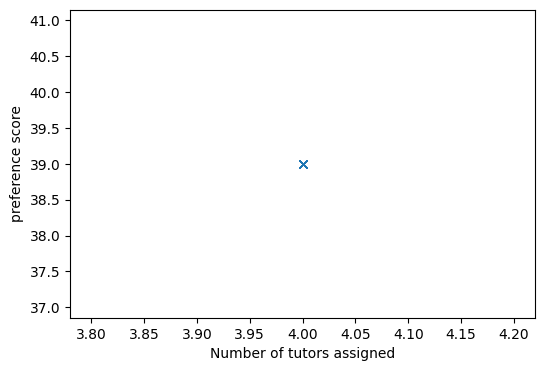

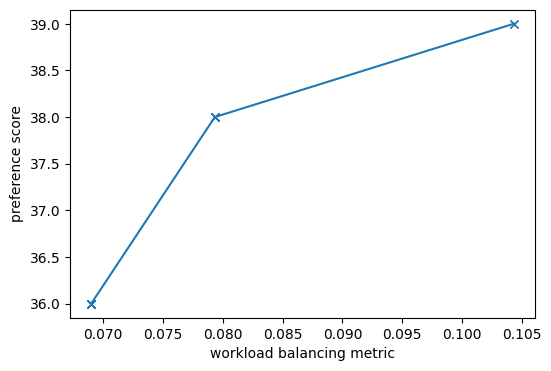

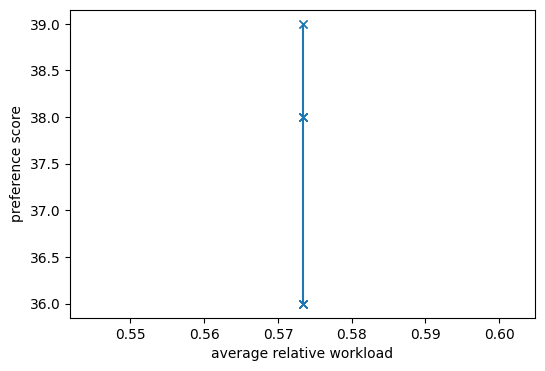

[0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.  ]
[39.0, 39.0, 38.0, 38.0, 38.0, 38.0, 38.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0]
[0.104333, 0.104333, 0.079333, 0.079333, 0.079333, 0.079333, 0.079333, 0.069, 0.069, 0.069, 0.069, 0.069, 0.069, 0.069, 0.069, 0.069, 0.069, 0.069, 0.069, 0.069, 0.069]


In [17]:
if RUN_SENSITIVITY_ANALYSIS:
    # Pareto frontiers.
    alphas = np.linspace(0, 1, 21)
    a_U = []
    a_P = []
    b_F = []
    b_P = []
    b_avrgw = []
    tsb_arr = []

    # # Don't need such strict tolerances for pareto.
    mdlB.parameters.threads = 10
    # to prevent degeneracy; add small eps value.
    eps = 1e-4

    for alpha in alphas:
        mdlA.minimize((alpha + eps) * U - (1 - alpha + eps) * P)
        solA = mdlA.solve()
        a_U.append(U.solution_value * 10)
        a_P.append(P.solution_value * 40)

        mdlB.minimize((10 * alpha + eps) * F - (1 - alpha + eps) * PB)
        solB = mdlB.solve(log_output=False)
        b_F.append(F.solution_value)
        b_P.append(PB.solution_value * 40)

        # tutor student mapping.
        tutor_students_B = {t: [] for t in T}

        for s in S:
            for t in T:
                if solB.get_value(xB[s, t]) > 0.5:
                    tutor_students_B[t].append(s)
                    break

        tsb_arr.append(tutor_students_B)

        # Workload balancing.
        new_count_B = {t: len(tutor_students_B[t]) for t in T}
        L_B = {t: e[t] + new_count_B[t] for t in T}
        rho_B = {t: (L_B[t] / m[t]) for t in T}
        rho_bar_B = sum(rho_B.values()) / len(T)
        b_avrgw.append(rho_bar_B)


    plt.style.use("default")
    plt.figure(figsize=(6, 4), facecolor="white")
    plt.plot(a_U, a_P, marker='x')
    plt.xlabel("Number of tutors assigned")
    plt.ylabel("preference score")
    plt.show()

    plt.figure(figsize=(6, 4), facecolor="white")
    plt.plot(b_F, b_P, marker='x')
    plt.xlabel("workload balancing metric")
    plt.ylabel("preference score")
    plt.show()

    plt.figure(figsize=(6, 4), facecolor="white")
    plt.plot(b_avrgw, b_P, marker='x')
    plt.xlabel("average relative workload")
    plt.ylabel("preference score")
    plt.show()

    print(alphas)
    print([round(a, 6) for a in b_P])
    print([round(a, 6) for a in b_F])

In [18]:
# examining unique solutions for scenario B.
def make_hashable(d):
    return frozenset((k, tuple(sorted(v))) for k, v in d.items())

if RUN_SENSITIVITY_ANALYSIS:
        unique_dicts = list({make_hashable(d): d for d in tsb_arr}.values())
        print(len(unique_dicts))

        list(map(print, unique_dicts))

3
{'A001': ['S0007'], 'A002': ['S0009', 'S0016', 'S0020'], 'A003': ['S0002', 'S0019'], 'A004': ['S0014', 'S0017'], 'A005': [], 'A006': ['S0001', 'S0004', 'S0015'], 'A007': [], 'A008': ['S0003', 'S0005', 'S0008'], 'A009': ['S0006', 'S0011'], 'A010': ['S0010', 'S0012', 'S0013', 'S0018']}
{'A001': ['S0006', 'S0015'], 'A002': ['S0009', 'S0016', 'S0020'], 'A003': ['S0002', 'S0010'], 'A004': ['S0014', 'S0017'], 'A005': [], 'A006': ['S0001', 'S0004', 'S0007'], 'A007': [], 'A008': ['S0005', 'S0008', 'S0018'], 'A009': ['S0003', 'S0011'], 'A010': ['S0012', 'S0013', 'S0019']}
{'A001': ['S0001', 'S0004', 'S0006'], 'A002': ['S0009', 'S0016', 'S0017'], 'A003': ['S0010', 'S0019'], 'A004': ['S0014', 'S0020'], 'A005': [], 'A006': ['S0007', 'S0011', 'S0015'], 'A007': [], 'A008': ['S0003', 'S0013', 'S0018'], 'A009': ['S0005', 'S0008'], 'A010': ['S0002', 'S0012']}
